# Modelo Predictivo de Admisión UNMSM
Este notebook implementa un sistema de Machine Learning para predecir la probabilidad de ingreso y la carrera ideal para postulantes a la Universidad Nacional Mayor de San Marcos.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import joblib

# Configuración de visualización
sns.set(style="whitegrid")
print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


## 2. Generación de Datos Sintéticos
Generaremos un dataset basado en las estadísticas de admisión: ~21% de tasa de ingreso y correlación entre notas de secundaria y éxito en el examen.

In [ ]:
def generar_dataset_unmsm(n=5000):
    np.random.seed(42)

    # Features básicas
    promedio_sec = np.random.normal(14, 2.5, n).clip(0, 20)
    nota_mat = (promedio_sec * 0.8 + np.random.normal(0, 2, n)).clip(0, 20)
    nota_com = (promedio_sec * 0.85 + np.random.normal(0, 1.5, n)).clip(0, 20)
    nota_cie = (promedio_sec * 0.75 + np.random.normal(0, 2.5, n)).clip(0, 20)

    # Categorías
    modalidades = ['Ordinario', 'CEPRE', 'Primeros Puestos']
    modalidad = np.random.choice(modalidades, n, p=[0.7, 0.2, 0.1])

    colegios = ['Público', 'Privado']
    tipo_colegio = np.random.choice(colegios, n)

    # Lógica de admisión (Target 1)
    # El puntaje de ingreso depende fuertemente de mate y comunicación
    score_potencial = (nota_mat * 0.4 + nota_com * 0.4 + promedio_sec * 0.2)
    umbral = np.percentile(score_potencial, 79) # Top 21% aproximadamente
    admitido = (score_potencial >= umbral).astype(int)

    # Carrera Ideal (Target 2)
    carreras = ['Medicina Humana', 'Ingeniería de Sistemas', 'Derecho', 'Psicología', 'Administración']
    carrera_ideal = []
    for i in range(n):
        if nota_mat[i] > 17 and nota_cie[i] > 16: carrera = 'Medicina Humana'
        elif nota_mat[i] > 15: carrera = 'Ingeniería de Sistemas'
        elif nota_com[i] > 16: carrera = 'Derecho'
        elif nota_cie[i] > 14: carrera = 'Psicología'
        else: carrera = 'Administración'
        carrera_ideal.append(carrera)

    df = pd.DataFrame({
        'promedio_secundaria': promedio_sec,
        'nota_matematicas': nota_mat,
        'nota_comunicacion': nota_com,
        'nota_ciencia': nota_cie,
        'modalidad_ingreso': modalidad,
        'tipo_colegio': tipo_colegio,
        'admitido': admitido,
        'carrera_ideal': carrera_ideal
    })
    return df

df_unmsm = generar_dataset_unmsm()
display(df_unmsm.head())
print(f"\nTasa de admisión generada: {df_unmsm['admitido'].mean():.2%}")

,promedio_secundaria,nota_matematicas,nota_comunicacion,nota_ciencia,modalidad_ingreso,tipo_colegio,admitido,carrera_ideal
0,15.241785,11.345909,11.937775,11.072781,Ordinario,Público,0,Administración
1,13.654339,10.016643,11.147939,10.159115,Primeros Puestos,Privado,0,Administración
2,15.619221,8.904091,12.380267,11.875153,CEPRE,Privado,0,Administración
3,17.807575,13.585879,15.302066,15.722835,CEPRE,Público,1,Psicología
4,13.414617,12.197351,13.198192,8.192919,Ordinario,Privado,0,Administración



Tasa de admisión generada: 21.00%


## 3. Análisis Exploratorio de Datos (EDA)
Visualizaremos la distribución de los datos y las relaciones entre las variables clave.

/tmp/ipykernel_1661/1613388401.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='admitido', data=df_unmsm, palette='viridis')
/tmp/ipykernel_1661/1613388401.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='admitido', y='promedio_secundaria', data=df_unmsm, palette='magma')


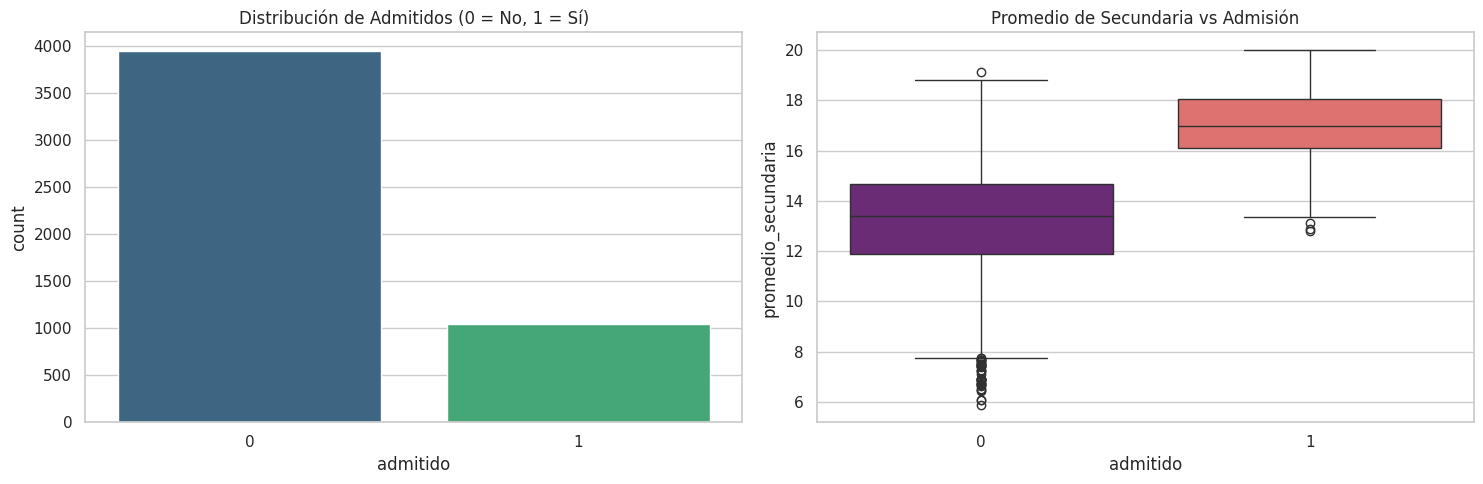

/tmp/ipykernel_1661/1613388401.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='carrera_ideal', data=df_unmsm, order=df_unmsm['carrera_ideal'].value_counts().index, palette='coolwarm')


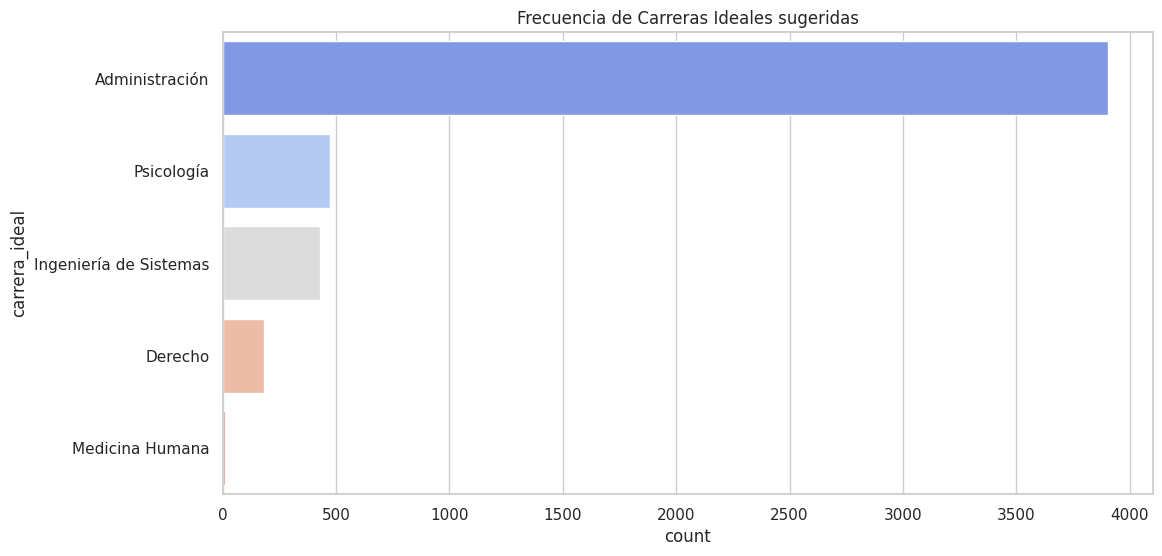

In [ ]:
plt.figure(figsize=(15, 5))

# Distribución de admitidos
plt.subplot(1, 2, 1)
sns.countplot(x='admitido', data=df_unmsm, palette='viridis')
plt.title('Distribución de Admitidos (0 = No, 1 = Sí)')

# Distribución de promedios por admisión
plt.subplot(1, 2, 2)
sns.boxplot(x='admitido', y='promedio_secundaria', data=df_unmsm, palette='magma')
plt.title('Promedio de Secundaria vs Admisión')

plt.tight_layout()
plt.show()

# Distribución de carreras ideales
plt.figure(figsize=(12, 6))
sns.countplot(y='carrera_ideal', data=df_unmsm, order=df_unmsm['carrera_ideal'].value_counts().index, palette='coolwarm')
plt.title('Frecuencia de Carreras Ideales sugeridas')
plt.show()

## 4. Preprocesamiento
Convertiremos las variables categóricas a numéricas y dividiremos el dataset para el entrenamiento.

In [ ]:
# Encoders para variables categóricas
le_modalidad = LabelEncoder()
le_colegio = LabelEncoder()
le_carrera = LabelEncoder()

df_prep = df_unmsm.copy()
df_prep['modalidad_ingreso'] = le_modalidad.fit_transform(df_prep['modalidad_ingreso'])
df_prep['tipo_colegio'] = le_colegio.fit_transform(df_prep['tipo_colegio'])
df_prep['carrera_ideal_encoded'] = le_carrera.fit_transform(df_prep['carrera_ideal'])

# Definir Features y Targets
X = df_prep.drop(['admitido', 'carrera_ideal', 'carrera_ideal_encoded'], axis=1)
y_admision = df_prep['admitido']
y_carrera = df_prep['carrera_ideal_encoded']

# División de datos (usando el mismo split para ambos modelos para consistencia)
X_train, X_test, y_train_adm, y_test_adm, y_train_car, y_test_car = train_test_split(
    X, y_admision, y_carrera, test_size=0.2, random_state=42
)

print(f"Set de entrenamiento: {X_train.shape[0]} muestras")
print(f"Set de prueba: {X_test.shape[0]} muestras")
print("\nClases de carrera mapeadas:", dict(enumerate(le_carrera.classes_)))

Set de entrenamiento: 4000 muestras
Set de prueba: 1000 muestras

Clases de carrera mapeadas: {0: 'Administración', 1: 'Derecho', 2: 'Ingeniería de Sistemas', 3: 'Medicina Humana', 4: 'Psicología'}


## 5. Modelo 1: ¿Será admitido? (Clasificación Binaria)
Entrenaremos un modelo para predecir la admisión basándonos en el perfil académico y personal.

=== Reporte de Clasificación - Admisión ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       796
           1       1.00      0.99      0.99       204

    accuracy                           1.00      1000
   macro avg       1.00      0.99      0.99      1000
weighted avg       1.00      1.00      1.00      1000



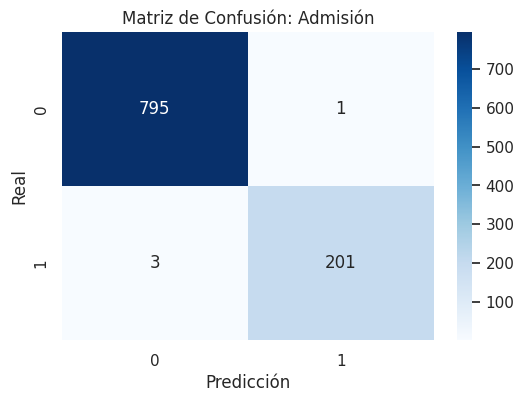

In [ ]:
# 1. Definir y entrenar el modelo
model_admision = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
model_admision.fit(X_train, y_train_adm)

# 2. Realizar predicciones
y_pred_adm = model_admision.predict(X_test)

# 3. Evaluación
print("=== Reporte de Clasificación - Admisión ===")
print(classification_report(y_test_adm, y_pred_adm))

# Matriz de Confusión
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test_adm, y_pred_adm), annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusión: Admisión')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.show()

## 6. Modelo 2: ¿Qué carrera? (Multi-class Classification)
Este modelo predice la carrera ideal basándose en el perfil de habilidades del estudiante.

=== Reporte de Clasificación - Carrera Ideal ===
                        precision    recall  f1-score   support

        Administración       1.00      1.00      1.00       765
               Derecho       1.00      1.00      1.00        37
Ingeniería de Sistemas       0.97      0.99      0.98        92
       Medicina Humana       0.00      0.00      0.00         3
            Psicología       1.00      1.00      1.00       103

              accuracy                           1.00      1000
             macro avg       0.79      0.80      0.80      1000
          weighted avg       0.99      1.00      0.99      1000



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


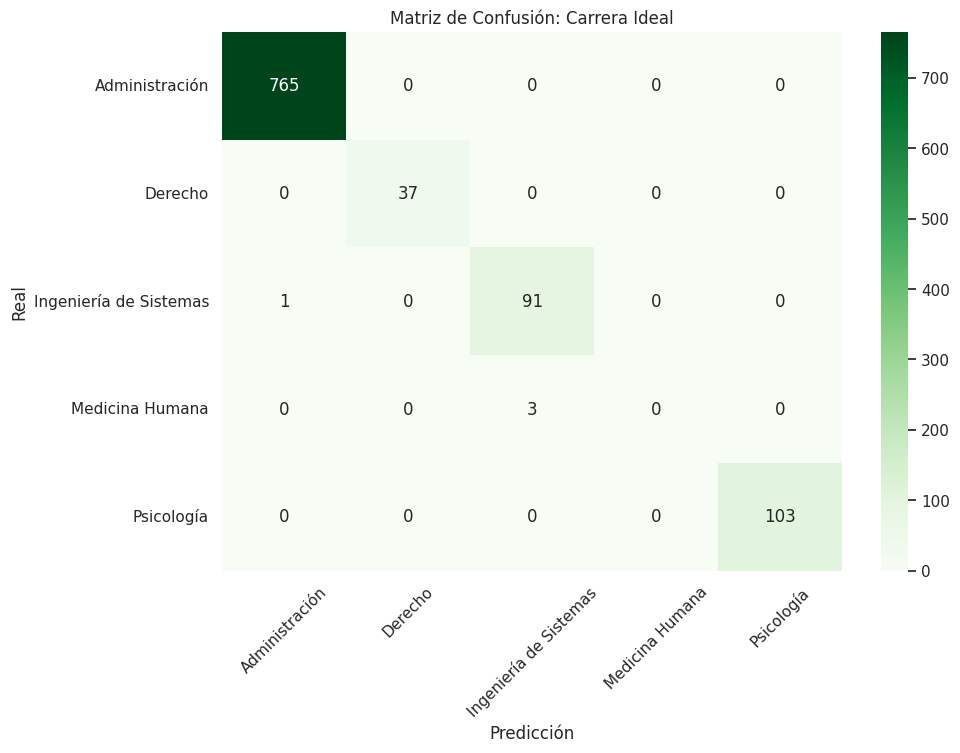

In [ ]:
# 1. Definir y entrenar el modelo de carrera
model_carrera = RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42)
model_carrera.fit(X_train, y_train_car)

# 2. Realizar predicciones
y_pred_car = model_carrera.predict(X_test)

# 3. Evaluación
print("=== Reporte de Clasificación - Carrera Ideal ===")
print(classification_report(y_test_car, y_pred_car, target_names=le_carrera.classes_))

# Matriz de Confusión para carreras
plt.figure(figsize=(10, 7))
sns.heatmap(confusion_matrix(y_test_car, y_pred_car), annot=True, fmt='d',
            xticklabels=le_carrera.classes_, yticklabels=le_carrera.classes_, cmap='Greens')
plt.title('Matriz de Confusión: Carrera Ideal')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.xticks(rotation=45)
plt.show()

## 7. Exportación de Modelos
Guardamos los modelos y transformadores para su uso posterior en producción.

In [ ]:
# Guardar modelos
joblib.dump(model_admision, 'modelo_admision_unmsm.pkl')
joblib.dump(model_carrera, 'modelo_carrera_unmsm.pkl')

# Guardar encoders para preprocesar nuevos datos
joblib.dump(le_modalidad, 'le_modalidad.pkl')
joblib.dump(le_colegio, 'le_colegio.pkl')
joblib.dump(le_carrera, 'le_carrera.pkl')

print("Todos los archivos .pkl han sido generados exitosamente.")

Todos los archivos .pkl han sido generados exitosamente.


## 8. Ejemplo de Uso (Simulador)
Función para predecir el futuro de un postulante.

In [ ]:
def simular_postulante(datos):
    # Convertir a DataFrame
    entrada = pd.DataFrame([datos])

    # Preprocesar
    entrada['modalidad_ingreso'] = le_modalidad.transform(entrada['modalidad_ingreso'])
    entrada['tipo_colegio'] = le_colegio.transform(entrada['tipo_colegio'])

    # Predecir
    ingresa = model_admision.predict(entrada)[0]
    prob = model_admision.predict_proba(entrada)[0][1]
    carrera_idx = model_carrera.predict(entrada)[0]
    carrera_nombre = le_carrera.inverse_transform([carrera_idx])[0]

    print(f"--- RESULTADOS DEL SIMULADOR ---")
    print(f"Probabilidad de ingreso: {prob:.2%}")
    print(f"Resultado: {'ADMITIDO' if ingresa == 1 else 'NO ADMITIDO'}")
    print(f"Carrera recomendada según perfil: {carrera_nombre}")

# Prueba con un ejemplo
postulante_test = {
    'promedio_secundaria': 17.5,
    'nota_matematicas': 18.0,
    'nota_comunicacion': 16.5,
    'nota_ciencia': 17.0,
    'modalidad_ingreso': 'Ordinario',
    'tipo_colegio': 'Privado'
}

simular_postulante(postulante_test)

--- RESULTADOS DEL SIMULADOR ---
Probabilidad de ingreso: 99.98%
Resultado: ADMITIDO
Carrera recomendada según perfil: Ingeniería de Sistemas


## 9. Funcionalidades Avanzadas para la App
En esta sección implementamos el motor lógico para el simulador interactivo, el ranking multivariable y el benchmark comparativo.

In [8]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier

# 1. Asegurar la generación completa del dataset
def generar_dataset_completo(n=5000):
    np.random.seed(42)
    promedio_sec = np.random.normal(14, 2.5, n).clip(0, 20)
    nota_mat = (promedio_sec * 0.8 + np.random.normal(0, 2, n)).clip(0, 20)
    nota_com = (promedio_sec * 0.85 + np.random.normal(0, 1.5, n)).clip(0, 20)
    nota_cie = (promedio_sec * 0.75 + np.random.normal(0, 2.5, n)).clip(0, 20)
    modalidades = ['Ordinario', 'CEPRE', 'Primeros Puestos']
    modalidad = np.random.choice(modalidades, n, p=[0.7, 0.2, 0.1])
    colegios = ['Público', 'Privado']
    tipo_colegio = np.random.choice(colegios, n)
    score = (nota_mat * 0.4 + nota_com * 0.4 + promedio_sec * 0.2)
    admitido = (score >= np.percentile(score, 79)).astype(int)
    carreras = ['Medicina Humana', 'Ingeniería de Sistemas', 'Derecho', 'Psicología', 'Administración']
    carrera_ideal = np.random.choice(carreras, n)
    return pd.DataFrame({
        'promedio_secundaria': promedio_sec, 'nota_matematicas': nota_mat,
        'nota_comunicacion': nota_com, 'nota_ciencia': nota_cie,
        'modalidad_ingreso': modalidad, 'tipo_colegio': tipo_colegio,
        'admitido': admitido, 'carrera_ideal': carrera_ideal
    })

df_unmsm = generar_dataset_completo()

le_modalidad, le_colegio, le_carrera = LabelEncoder(), LabelEncoder(), LabelEncoder()
df_prep = df_unmsm.copy()
df_prep['modalidad_ingreso'] = le_modalidad.fit_transform(df_prep['modalidad_ingreso'])
df_prep['tipo_colegio'] = le_colegio.fit_transform(df_prep['tipo_colegio'])
df_prep['carrera_ideal_encoded'] = le_carrera.fit_transform(df_prep['carrera_ideal'])

X = df_prep.drop(['admitido', 'carrera_ideal', 'carrera_ideal_encoded'], axis=1)
model_admision = RandomForestClassifier(n_estimators=50, random_state=42).fit(X, df_prep['admitido'])
model_carrera = RandomForestClassifier(n_estimators=50, random_state=42).fit(X, df_prep['carrera_ideal_encoded'])

def motor_logico_app(datos_usuario, df_historico):
    entrada = pd.DataFrame([datos_usuario])
    entrada['modalidad_ingreso'] = le_modalidad.transform(entrada['modalidad_ingreso'])
    entrada['tipo_colegio'] = le_colegio.transform(entrada['tipo_colegio'])
    entrada_final = entrada[X.columns]

    # 1. Simulador "¿Qué pasa si...?"
    prob_actual = model_admision.predict_proba(entrada_final)[0][1]
    entrada_alt = entrada_final.copy()
    entrada_alt['nota_matematicas'] = min(20, entrada_alt['nota_matematicas'].values[0] + 3)
    prob_alt = model_admision.predict_proba(entrada_alt)[0][1]

    # 2. Ranking de carreras
    probs_c = model_carrera.predict_proba(entrada_final)[0]
    ranking = pd.DataFrame({'Carrera': le_carrera.classes_, 'Compatibilidad': probs_c}).sort_values(by='Compatibilidad', ascending=False)

    # 3. Benchmark Anónimo
    admitidos = df_historico[df_historico['admitido'] == 1]
    avg_ingresantes = admitidos[['promedio_secundaria', 'nota_matematicas', 'nota_comunicacion']].mean()

    print(f"📊 PROBABILIDAD DE INGRESO: {prob_actual:.2%}")
    print(f"💡 SIMULADOR: Si subes +3 en Matemáticas, tu probabilidad sería {prob_alt:.2%}")

    print("\n🏆 RANKING DE CARRERAS:")
    print(ranking.head(3).to_string(index=False))

    print("\n👥 BENCHMARK: Estudiantes que entraron en 2023 tenían:")
    print(f"- Promedio: {avg_ingresantes['promedio_secundaria']:.2f} (Tú: {datos_usuario['promedio_secundaria']})")
    print(f"- Matemáticas: {avg_ingresantes['nota_matematicas']:.2f} (Tú: {datos_usuario['nota_matematicas']})")

    # 4. Plan de estudio personalizado
    print("\n📅 PLAN DE ESTUDIO RECOMENDADO:")
    if datos_usuario['nota_matematicas'] < avg_ingresantes['nota_matematicas']:
        print("- Prioridad: Reforzar Álgebra y Aritmética (estás bajo el promedio de ingresantes).")
    if datos_usuario['nota_comunicacion'] < 16:
        print("- Táctica: Aumentar lectura crítica 30 min al día.")

perfil = {'promedio_secundaria': 14.5, 'nota_matematicas': 13.0, 'nota_comunicacion': 15.0, 'nota_ciencia': 12.0, 'modalidad_ingreso': 'Ordinario', 'tipo_colegio': 'Público'}
motor_logico_app(perfil, df_unmsm)

📊 PROBABILIDAD DE INGRESO: 56.00%
💡 SIMULADOR: Si subes +3 en Matemáticas, tu probabilidad sería 92.00%

🏆 RANKING DE CARRERAS:
               Carrera  Compatibilidad
        Administración            0.24
Ingeniería de Sistemas            0.22
       Medicina Humana            0.20

👥 BENCHMARK: Estudiantes que entraron en 2023 tenían:
- Promedio: 17.07 (Tú: 14.5)
- Matemáticas: 14.54 (Tú: 13.0)

📅 PLAN DE ESTUDIO RECOMENDADO:
- Prioridad: Reforzar Álgebra y Aritmética (estás bajo el promedio de ingresantes).
- Táctica: Aumentar lectura crítica 30 min al día.
